# Analisi dello Spazio Latente — ChessVQVAE

Questo notebook analizza il codebook e lo spazio latente del VQ-VAE addestrato su posizioni di scacchi.

**Struttura:**
1. Setup e caricamento modello
2. Statistica del codebook (utilizzo, distribuzione)
3. PCA del codebook
4. t-SNE delle posizioni encodate
5. UMAP (se disponibile)
6. Clustering (K-Means) dello spazio latente
7. Analisi semantica: cosa rappresenta ogni cluster?
8. Interpolazione nello spazio latente
9. Nearest neighbors nel codebook

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter
import chess
import chess.svg
from IPython.display import display, SVG
import warnings
warnings.filterwarnings('ignore')

import sys, os
current_dir = os.getcwd()
if current_dir in sys.path:
    sys.path.remove(current_dir)
    sys.path.append(current_dir)

from vqvae_chess import ChessVQVAE
from MLChess import create_dataloaders_tensor, ChessTransform, generate_all_legal_move_vocab

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

plt.style.use('dark_background')
sns.set_palette('husl')


Device: cuda


## 1. Caricamento modello e dati

In [2]:
# ── CONFIGURA QUI ──────────────────────────────────────────
CHECKPOINT_PATH = './runs/vqvae/checkpoints/best.pt'
CSV_PATH        = '../over_mate_1_tactic_evals.csv'
N_SAMPLES       = 10_000   # quante posizioni analizzare (aumenta se hai RAM)
BATCH_SIZE      = 512
# ───────────────────────────────────────────────────────────

# Carica checkpoint
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
cfg  = ckpt['cfg']
print('Config salvata:', cfg)

model = ChessVQVAE(
    latent_dim     = cfg['latent_dim'],
    num_embeddings = cfg['num_embeddings'],
    base_ch        = cfg['base_ch'],
    beta           = cfg['beta'],
    focal_alpha    = cfg['focal_alpha'],
    focal_gamma    = cfg['focal_gamma'],
).to(device)

model.load_state_dict(ckpt['model'])
model.eval()
print(f'Modello caricato — epoch {ckpt["epoch"]}, val_loss {ckpt["best_val_loss"]:.4f}')

Config salvata: {'csv': '../over_mate_1_tactic_evals.csv', 'batch_size': 256, 'latent_dim': 256, 'num_embeddings': 512, 'base_ch': 128, 'beta': 0.5, 'focal_alpha': 0.85, 'focal_gamma': 2.0, 'epochs': 50, 'lr': 0.0003, 'weight_decay': 0.0001, 'min_lr_ratio': 0.1, 'warmup_epochs': 2, 'dead_reset_every': 200, 'grad_accum': 4, 'aux_weight': 0.5, 'output_dir': './runs/vqvae', 'save_every': 5, 'patience': 10, 'resume': ''}
Modello caricato — epoch 3, val_loss 0.1111


In [3]:
# Carica un campione dal dataset
trainloader, valloader, testloader, move_vocab = create_dataloaders_tensor(
    name_file=CSV_PATH, batch_size=BATCH_SIZE
)

# Raccoglie N_SAMPLES posizioni con metadati
all_positions  = []   # tensori (13,8,8)
all_fens       = []   # stringhe FEN originali
all_evals      = []   # valutazione centipawns

# Legge direttamente il CSV per avere i FEN
df = pd.read_csv(CSV_PATH)
df_val = df.iloc[int(len(df)*0.7):int(len(df)*0.85)].reset_index(drop=True)
df_sample = df_val.sample(n=min(N_SAMPLES, len(df_val)), random_state=42).reset_index(drop=True)

all_moves = generate_all_legal_move_vocab()
transform = ChessTransform(move_vocab=all_moves)

for _, row in df_sample.iterrows():
    pos_tensor, _, _, ev = transform(row['FEN'], row['Move'], [], row['Evaluation'])
    all_positions.append(pos_tensor)
    all_fens.append(row['FEN'])
    all_evals.append(float(ev))

positions_tensor = torch.stack(all_positions).to(device)  # (N, 13, 8, 8)
evals_np = np.array(all_evals)
print(f'Caricate {len(all_positions)} posizioni')

Train set size: 1689648
Validation set size: 362068
Test set size: 362068
Caricate 10000 posizioni


In [4]:
# Encoding in batch
all_indices   = []   # indici VQ per ogni posizione: (N, 4) perché H'W'=2x2
all_z_e       = []   # vettori encoder pre-VQ
all_z_q       = []   # vettori quantizzati

with torch.no_grad():
    for i in range(0, len(positions_tensor), BATCH_SIZE):
        batch = positions_tensor[i:i+BATCH_SIZE]
        z_e = model.encoder(batch)                       # (B, D, 2, 2)
        z_q, _, _, idx = model.vq(z_e)                  # idx: (B*4,)
        
        B = batch.shape[0]
        all_indices.append(idx.reshape(B, 4).cpu())      # (B, 4)
        all_z_e.append(z_e.reshape(B, -1).cpu())         # (B, D*4)
        all_z_q.append(z_q.reshape(B, -1).cpu())         # (B, D*4)

indices_np = torch.cat(all_indices).numpy()              # (N, 4)
z_e_np     = torch.cat(all_z_e).float().numpy()          # (N, D*4)
z_q_np     = torch.cat(all_z_q).float().numpy()          # (N, D*4)

print(f'z_e shape: {z_e_np.shape}')
print(f'z_q shape: {z_q_np.shape}')
print(f'indices shape: {indices_np.shape}')

z_e shape: (10000, 1024)
z_q shape: (10000, 1024)
indices shape: (10000, 4)


## 2. Statistica del Codebook

Vettori usati:    512 / 512 (100.0%)
Entropia:         6.140 / 6.238 (max teorico)
Perplexity:       464.2 / 512


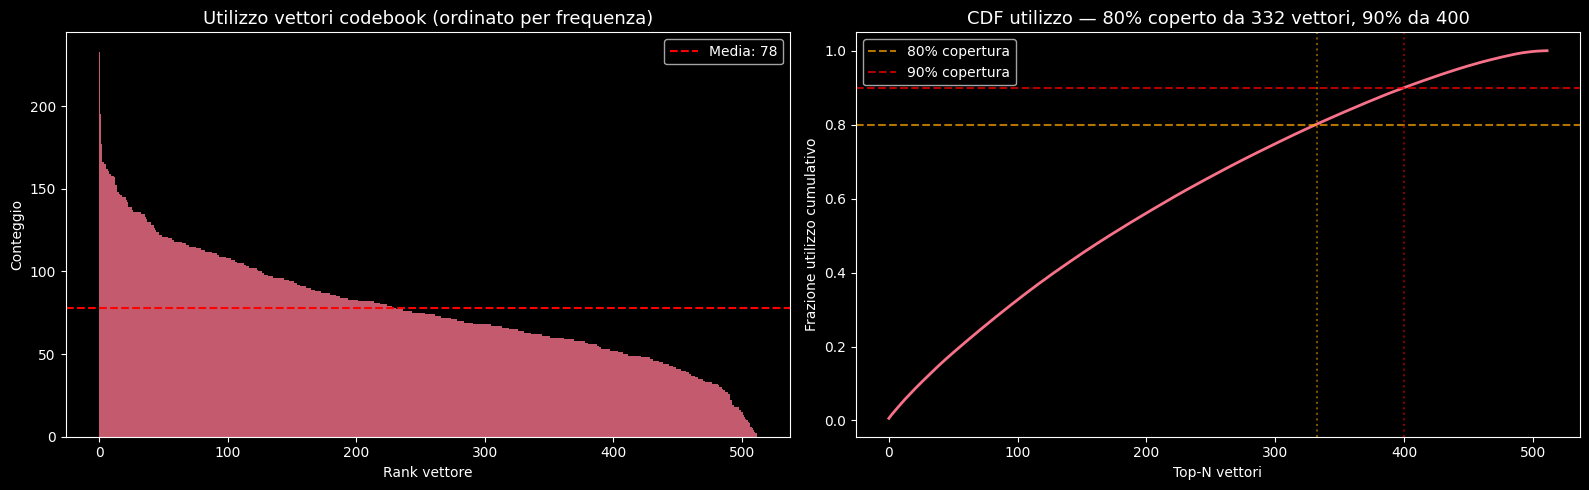

In [5]:
K = cfg['num_embeddings']
all_idx_flat = indices_np.flatten()   # ogni posizione ha 4 indici → N*4 valori

counts = np.bincount(all_idx_flat, minlength=K)
used   = (counts > 0).sum()
probs  = counts / counts.sum()
entropy = -np.sum(probs[probs > 0] * np.log(probs[probs > 0]))
perplexity = np.exp(entropy)

print(f'Vettori usati:    {used} / {K} ({100*used/K:.1f}%)')
print(f'Entropia:         {entropy:.3f} / {np.log(K):.3f} (max teorico)')
print(f'Perplexity:       {perplexity:.1f} / {K}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Istogramma utilizzi
axes[0].bar(np.arange(K), np.sort(counts)[::-1], width=1.0, alpha=0.8)
axes[0].set_title('Utilizzo vettori codebook (ordinato per frequenza)', fontsize=13)
axes[0].set_xlabel('Rank vettore')
axes[0].set_ylabel('Conteggio')
axes[0].axhline(counts.mean(), color='red', linestyle='--', label=f'Media: {counts.mean():.0f}')
axes[0].legend()

# CDF dell'utilizzo
sorted_counts = np.sort(counts)[::-1]
cdf = np.cumsum(sorted_counts) / sorted_counts.sum()
axes[1].plot(np.arange(K), cdf, linewidth=2)
axes[1].axhline(0.8, color='orange', linestyle='--', alpha=0.7, label='80% copertura')
axes[1].axhline(0.9, color='red',    linestyle='--', alpha=0.7, label='90% copertura')
idx_80 = np.searchsorted(cdf, 0.8)
idx_90 = np.searchsorted(cdf, 0.9)
axes[1].axvline(idx_80, color='orange', linestyle=':', alpha=0.5)
axes[1].axvline(idx_90, color='red',    linestyle=':', alpha=0.5)
axes[1].set_title(f'CDF utilizzo — 80% coperto da {idx_80} vettori, 90% da {idx_90}', fontsize=13)
axes[1].set_xlabel('Top-N vettori')
axes[1].set_ylabel('Frazione utilizzo cumulativo')
axes[1].legend()

plt.tight_layout()
plt.savefig('codebook_usage.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. PCA del Codebook

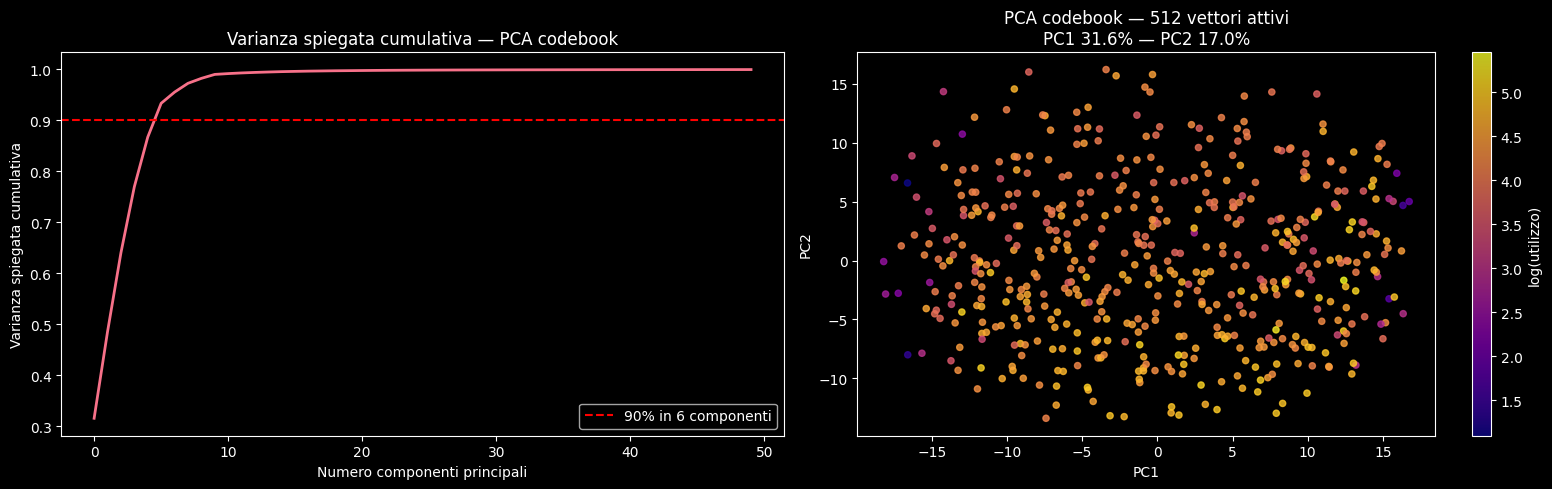

Varianza spiegata da 2 PC: 48.5%
Componenti per spiegare 90%: 6


In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Prende solo i vettori usati
used_mask    = counts > 0
codebook_np  = model.vq.embedding.weight.detach().cpu().float().numpy()  # (K, D)
used_vecs    = codebook_np[used_mask]
used_counts  = counts[used_mask]
used_indices = np.where(used_mask)[0]

scaler = StandardScaler()
vecs_scaled = scaler.fit_transform(used_vecs)

pca = PCA(n_components=min(50, used_vecs.shape[0]))
pca.fit(vecs_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Varianza spiegata
cumvar = np.cumsum(pca.explained_variance_ratio_)
n90    = np.searchsorted(cumvar, 0.9) + 1
axes[0].plot(cumvar, linewidth=2)
axes[0].axhline(0.9, color='red', linestyle='--', label=f'90% in {n90} componenti')
axes[0].set_title('Varianza spiegata cumulativa — PCA codebook')
axes[0].set_xlabel('Numero componenti principali')
axes[0].set_ylabel('Varianza spiegata cumulativa')
axes[0].legend()

# Scatter PC1 vs PC2, colorato per frequenza
pca2 = PCA(n_components=2)
coords_2d = pca2.fit_transform(vecs_scaled)
sc = axes[1].scatter(coords_2d[:, 0], coords_2d[:, 1],
                     c=np.log1p(used_counts), cmap='plasma',
                     s=20, alpha=0.8)
plt.colorbar(sc, ax=axes[1], label='log(utilizzo)')
axes[1].set_title(f'PCA codebook — {used} vettori attivi\n'
                  f'PC1 {pca2.explained_variance_ratio_[0]*100:.1f}% — '
                  f'PC2 {pca2.explained_variance_ratio_[1]*100:.1f}%')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('codebook_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Varianza spiegata da 2 PC: {cumvar[1]*100:.1f}%')
print(f'Componenti per spiegare 90%: {n90}')

## 4. t-SNE delle posizioni encodate

In [8]:
from sklearn.manifold import TSNE

# Usa z_q (post-VQ) per la t-SNE — è lo spazio più significativo
# Riduciamo prima con PCA a 50 dim per velocità
N_TSNE = min(5000, len(z_q_np))  # la t-SNE è lenta, limitiamo
idx_sample = np.random.choice(len(z_q_np), N_TSNE, replace=False)

z_q_sample   = z_q_np[idx_sample]
evals_sample = evals_np[idx_sample]
fens_sample  = [all_fens[i] for i in idx_sample]

# PCA preprocessing
pca50 = PCA(n_components=min(50, z_q_sample.shape[1]))
z_pca = pca50.fit_transform(StandardScaler().fit_transform(z_q_sample))
print(f'Varianza spiegata da 50 PC: {pca50.explained_variance_ratio_.sum()*100:.1f}%')

print(f'Avvio t-SNE su {N_TSNE} posizioni...')
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            learning_rate='auto', init='pca', random_state=42, verbose=1)
z_tsne = tsne.fit_transform(z_pca)
print('t-SNE completata')

Varianza spiegata da 50 PC: 99.7%
Avvio t-SNE su 5000 posizioni...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.001s...
[t-SNE] Computed neighbors for 5000 samples in 0.138s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 9.344210
[t-SNE] KL divergence after 250 iterations with early exaggeration: 77.514160
[t-SNE] KL divergence after 1000 iterations: 1.893249
t-SNE completata


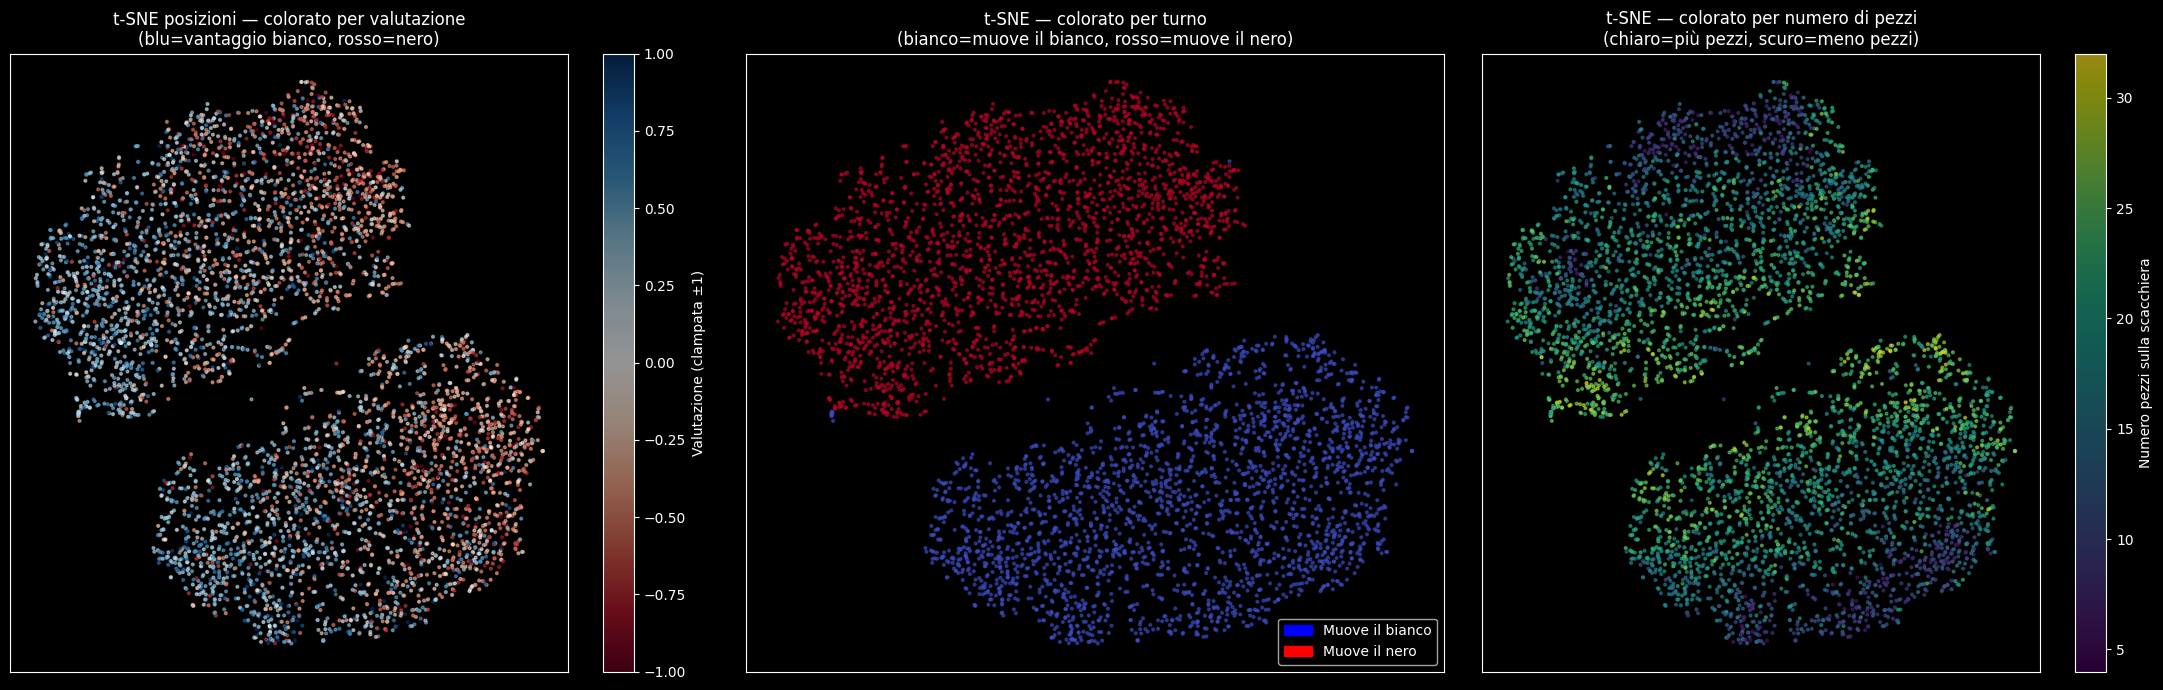

In [9]:
# Colora per valutazione
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Plot 1: colorato per valutazione ──
sc1 = axes[0].scatter(z_tsne[:, 0], z_tsne[:, 1],
                      c=np.clip(evals_sample, -1, 1),
                      cmap='RdBu', s=4, alpha=0.6, vmin=-1, vmax=1)
plt.colorbar(sc1, ax=axes[0], label='Valutazione (clampata ±1)')
axes[0].set_title('t-SNE posizioni — colorato per valutazione\n(blu=vantaggio bianco, rosso=nero)')
axes[0].set_xticks([]); axes[0].set_yticks([])

# ── Plot 2: colorato per turno ──
turns = np.array([1.0 if 'w' in fen.split()[1] else 0.0 for fen in fens_sample])
sc2 = axes[1].scatter(z_tsne[:, 0], z_tsne[:, 1],
                      c=turns, cmap='coolwarm', s=4, alpha=0.6)
axes[1].set_title('t-SNE — colorato per turno\n(bianco=muove il bianco, rosso=muove il nero)')
axes[1].set_xticks([]); axes[1].set_yticks([])
w_patch = mpatches.Patch(color='blue',  label='Muove il bianco')
b_patch = mpatches.Patch(color='red',   label='Muove il nero')
axes[1].legend(handles=[w_patch, b_patch], loc='lower right')

# ── Plot 3: colorato per numero di pezzi sulla scacchiera ──
n_pieces = np.array([
    sum(1 for sq in chess.Board(fen).piece_map())
    for fen in fens_sample
])
sc3 = axes[2].scatter(z_tsne[:, 0], z_tsne[:, 1],
                      c=n_pieces, cmap='viridis', s=4, alpha=0.6)
plt.colorbar(sc3, ax=axes[2], label='Numero pezzi sulla scacchiera')
axes[2].set_title('t-SNE — colorato per numero di pezzi\n(chiaro=più pezzi, scuro=meno pezzi)')
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.tight_layout()
plt.savefig('tsne_positions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. UMAP (opzionale, più veloce e spesso più informativo di t-SNE)

In [10]:
try:
    import umap
    print('UMAP disponibile')
    HAS_UMAP = True
except ImportError:
    print('UMAP non installato. Installa con: pip install umap-learn')
    HAS_UMAP = False

2026-03-05 21:48:56.277472: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


UMAP disponibile


Avvio UMAP su 10000 posizioni...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Thu Mar  5 21:48:58 2026 Construct fuzzy simplicial set
Thu Mar  5 21:48:58 2026 Finding Nearest Neighbors
Thu Mar  5 21:48:58 2026 Building RP forest with 10 trees
Thu Mar  5 21:49:03 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Thu Mar  5 21:49:14 2026 Finished Nearest Neighbor Search
Thu Mar  5 21:49:16 2026 Construct embedding


Epochs completed:   1%| ▏          7/500 [00:00]

	completed  0  /  500 epochs


Epochs completed:  12%| █▏         59/500 [00:02]

	completed  50  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  92%| █████████▏ 459/500 [00:15]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:16]


Thu Mar  5 21:49:33 2026 Finished embedding
UMAP completata


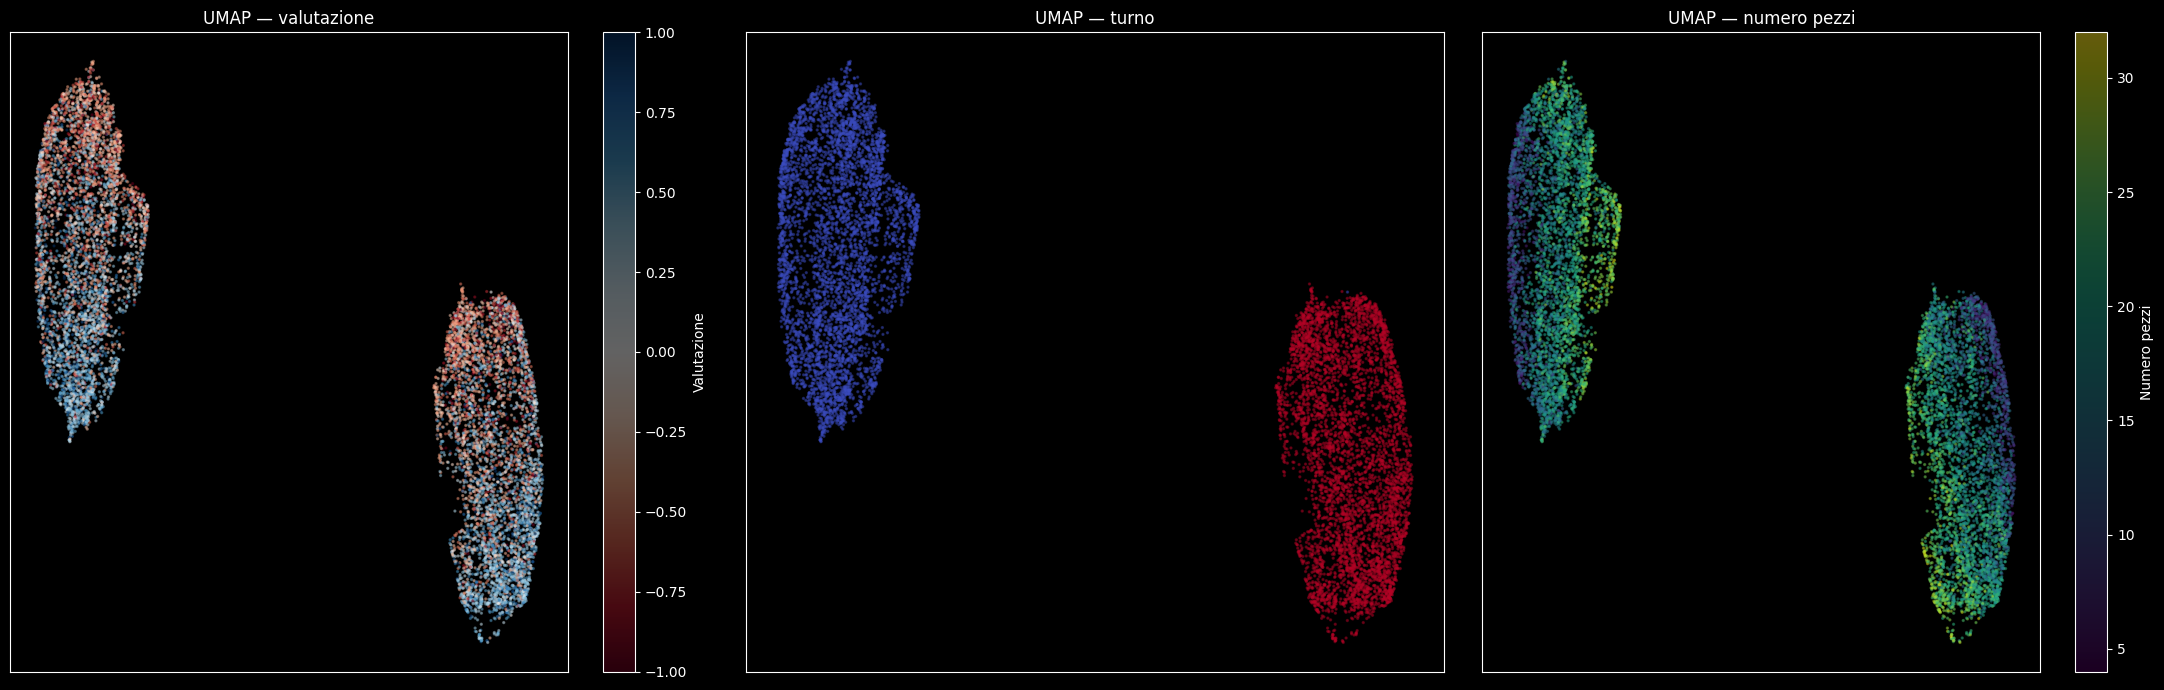

In [11]:
if HAS_UMAP:
    # UMAP su tutte le posizioni (è molto più veloce di t-SNE)
    print(f'Avvio UMAP su {len(z_q_np)} posizioni...')
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                        metric='cosine', random_state=42, verbose=True)
    z_umap = reducer.fit_transform(StandardScaler().fit_transform(z_q_np))
    print('UMAP completata')

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    sc1 = axes[0].scatter(z_umap[:, 0], z_umap[:, 1],
                          c=np.clip(evals_np, -1, 1),
                          cmap='RdBu', s=2, alpha=0.4, vmin=-1, vmax=1)
    plt.colorbar(sc1, ax=axes[0], label='Valutazione')
    axes[0].set_title('UMAP — valutazione')
    axes[0].set_xticks([]); axes[0].set_yticks([])

    turns_all = np.array([1.0 if 'w' in fen.split()[1] else 0.0 for fen in all_fens])
    sc2 = axes[1].scatter(z_umap[:, 0], z_umap[:, 1],
                          c=turns_all, cmap='coolwarm', s=2, alpha=0.4)
    axes[1].set_title('UMAP — turno')
    axes[1].set_xticks([]); axes[1].set_yticks([])

    n_pieces_all = np.array([
        len(chess.Board(fen).piece_map()) for fen in all_fens
    ])
    sc3 = axes[2].scatter(z_umap[:, 0], z_umap[:, 1],
                          c=n_pieces_all, cmap='viridis', s=2, alpha=0.4)
    plt.colorbar(sc3, ax=axes[2], label='Numero pezzi')
    axes[2].set_title('UMAP — numero pezzi')
    axes[2].set_xticks([]); axes[2].set_yticks([])

    plt.tight_layout()
    plt.savefig('umap_positions.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Clustering K-Means dello spazio latente

Calcolo elbow method...
  k=  4  inertia=6858771
  k=  8  inertia=6088206
  k= 12  inertia=5627920
  k= 16  inertia=5386167
  k= 20  inertia=5144351
  k= 24  inertia=5014763
  k= 32  inertia=4727642
  k= 48  inertia=4422487
  k= 64  inertia=4184991


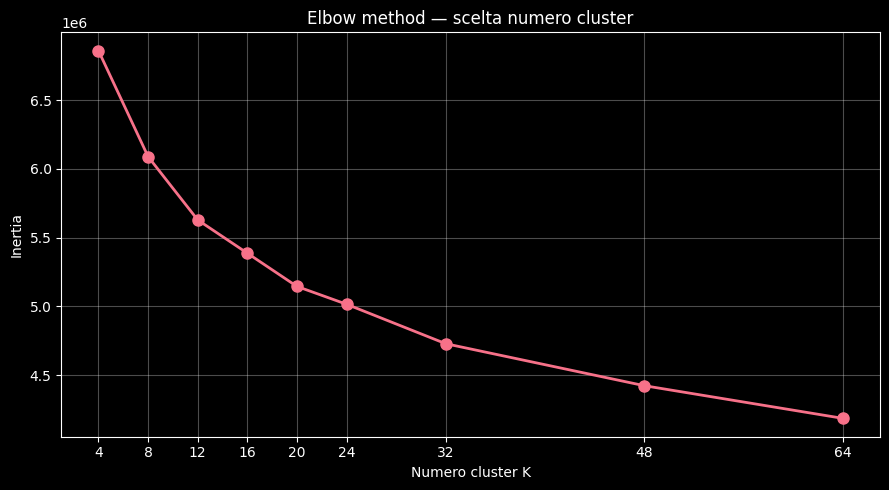

In [12]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score

# Trova il numero ottimale di cluster con elbow method
# Usa MiniBatchKMeans per velocità su N_SAMPLES grandi
inertias = []
K_range  = [4, 8, 12, 16, 20, 24, 32, 48, 64]

z_scaled = StandardScaler().fit_transform(z_q_np)

print('Calcolo elbow method...')
for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=2048)
    km.fit(z_scaled)
    inertias.append(km.inertia_)
    print(f'  k={k:3d}  inertia={km.inertia_:.0f}')

plt.figure(figsize=(9, 5))
plt.plot(K_range, inertias, 'o-', linewidth=2, markersize=8)
plt.xlabel('Numero cluster K')
plt.ylabel('Inertia')
plt.title('Elbow method — scelta numero cluster')
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

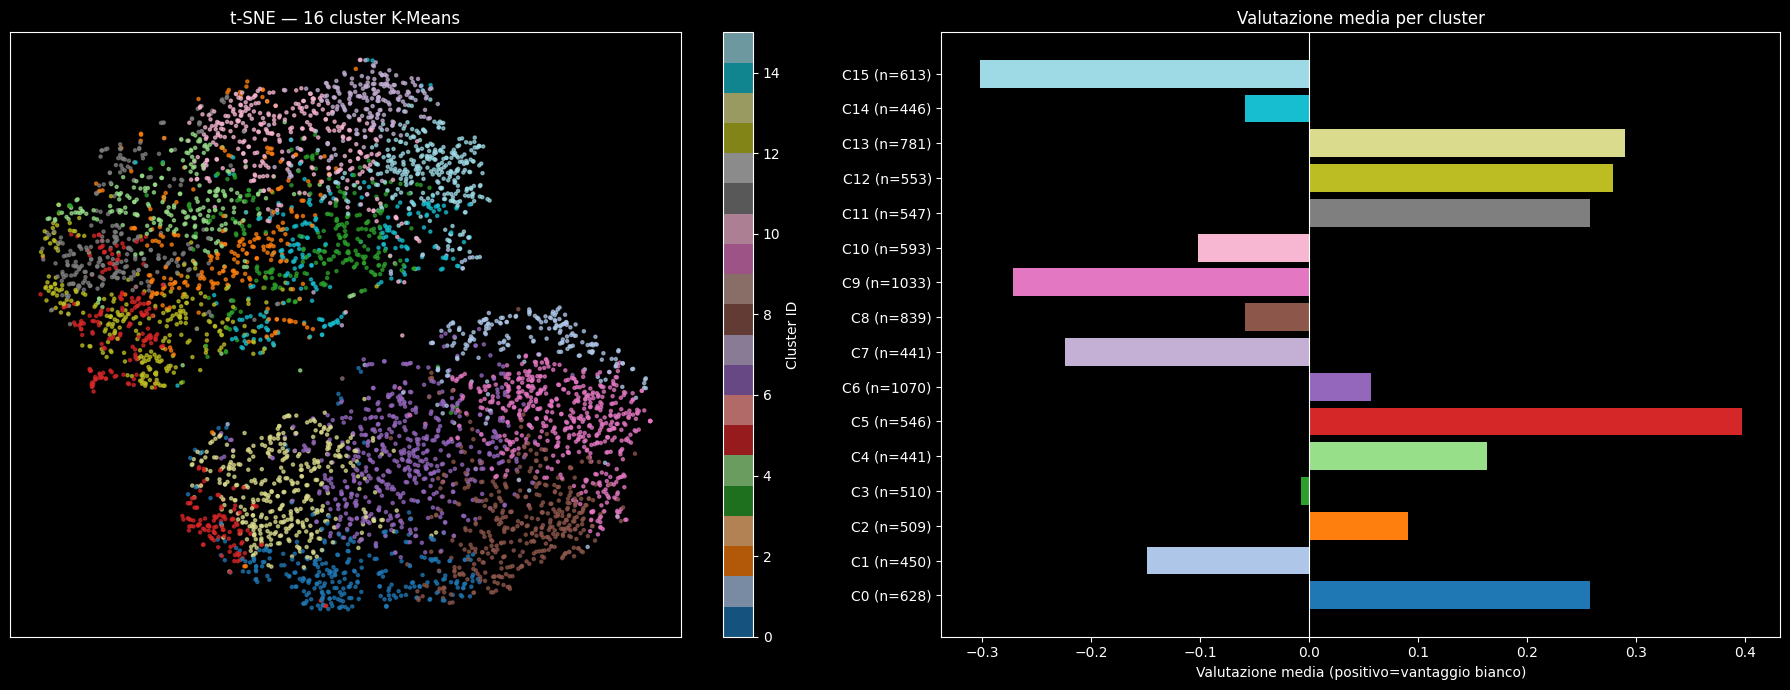

In [13]:
# Scegli K basandoti sull'elbow plot sopra, poi modifica questa variabile
K_FINAL = 16

km_final = MiniBatchKMeans(n_clusters=K_FINAL, random_state=42, n_init=10, batch_size=2048)
cluster_labels = km_final.fit_predict(z_scaled)

# Visualizza cluster sulla t-SNE
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Cluster
sc = axes[0].scatter(z_tsne[:, 0], z_tsne[:, 1],
                     c=cluster_labels[idx_sample],
                     cmap='tab20', s=5, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='Cluster ID')
axes[0].set_title(f't-SNE — {K_FINAL} cluster K-Means')
axes[0].set_xticks([]); axes[0].set_yticks([])

# Statistiche per cluster
cluster_evals = [evals_np[cluster_labels == c].mean() for c in range(K_FINAL)]
cluster_sizes = [( cluster_labels == c).sum() for c in range(K_FINAL)]
colors = plt.cm.tab20(np.linspace(0, 1, K_FINAL))
bars = axes[1].barh(range(K_FINAL), cluster_evals, color=colors)
axes[1].set_yticks(range(K_FINAL))
axes[1].set_yticklabels([f'C{c} (n={cluster_sizes[c]})' for c in range(K_FINAL)])
axes[1].axvline(0, color='white', linestyle='-', linewidth=0.8)
axes[1].set_xlabel('Valutazione media (positivo=vantaggio bianco)')
axes[1].set_title('Valutazione media per cluster')

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Analisi semantica dei cluster — cosa rappresenta ogni gruppo?

In [14]:
def extract_features(fen: str) -> dict:
    """Estrae feature semantiche da una posizione FEN."""
    board = chess.Board(fen)
    pieces = board.piece_map()
    
    n_white = sum(1 for p in pieces.values() if p.color == chess.WHITE)
    n_black = sum(1 for p in pieces.values() if p.color == chess.BLACK)
    
    has_queens_w = any(p.piece_type == chess.QUEEN and p.color == chess.WHITE for p in pieces.values())
    has_queens_b = any(p.piece_type == chess.QUEEN and p.color == chess.BLACK for p in pieces.values())
    
    # Fase della partita stimata
    total = len(pieces)
    if   total >= 28: phase = 'apertura'
    elif total >= 16: phase = 'mediogioco'
    else:             phase = 'finale'
    
    # Centro di massa dei pezzi (0-7 per file/rank)
    white_squares = [sq for sq, p in pieces.items() if p.color == chess.WHITE]
    black_squares = [sq for sq, p in pieces.items() if p.color == chess.BLACK]
    
    wc = np.mean([chess.square_rank(sq) for sq in white_squares]) if white_squares else 3.5
    bc = np.mean([chess.square_rank(sq) for sq in black_squares]) if black_squares else 3.5
    
    return {
        'n_pieces':    total,
        'n_white':     n_white,
        'n_black':     n_black,
        'phase':       phase,
        'has_q_white': int(has_queens_w),
        'has_q_black': int(has_queens_b),
        'turn':        1 if board.turn == chess.WHITE else 0,
        'white_rank':  wc,    # rank medio pezzi bianchi (alto = avanzati)
        'black_rank':  bc,
    }

# Estrae feature per tutti i campioni (può volerci un minuto)
print('Estrazione feature semantiche...')
features = [extract_features(fen) for fen in all_fens]
df_feat  = pd.DataFrame(features)
df_feat['cluster'] = cluster_labels
df_feat['eval']    = evals_np
print('Fatto')

Estrazione feature semantiche...
Fatto



=== Profilo semantico dei cluster ===
            n  pezzi_med  eval_med  turno_w  q_white  q_black        fase
cluster                                                                  
0         628     13.508     0.258    0.000    0.468    0.381      finale
1         450     24.118    -0.149    0.078    0.922    0.909  mediogioco
2         509     18.214     0.091    0.994    0.711    0.741  mediogioco
3         510     21.212    -0.007    0.992    0.857    0.912  mediogioco
4         441     17.927     0.163    0.998    0.757    0.780  mediogioco
5         546     19.861     0.397    0.557    0.830    0.778  mediogioco
6        1070     19.888     0.057    0.000    0.872    0.813  mediogioco
7         441     13.091    -0.223    0.993    0.281    0.351      finale
8         839     12.768    -0.059    0.000    0.324    0.308      finale
9        1033     19.973    -0.272    0.000    0.883    0.856  mediogioco
10        593     13.368    -0.102    0.998    0.331    0.374      finale

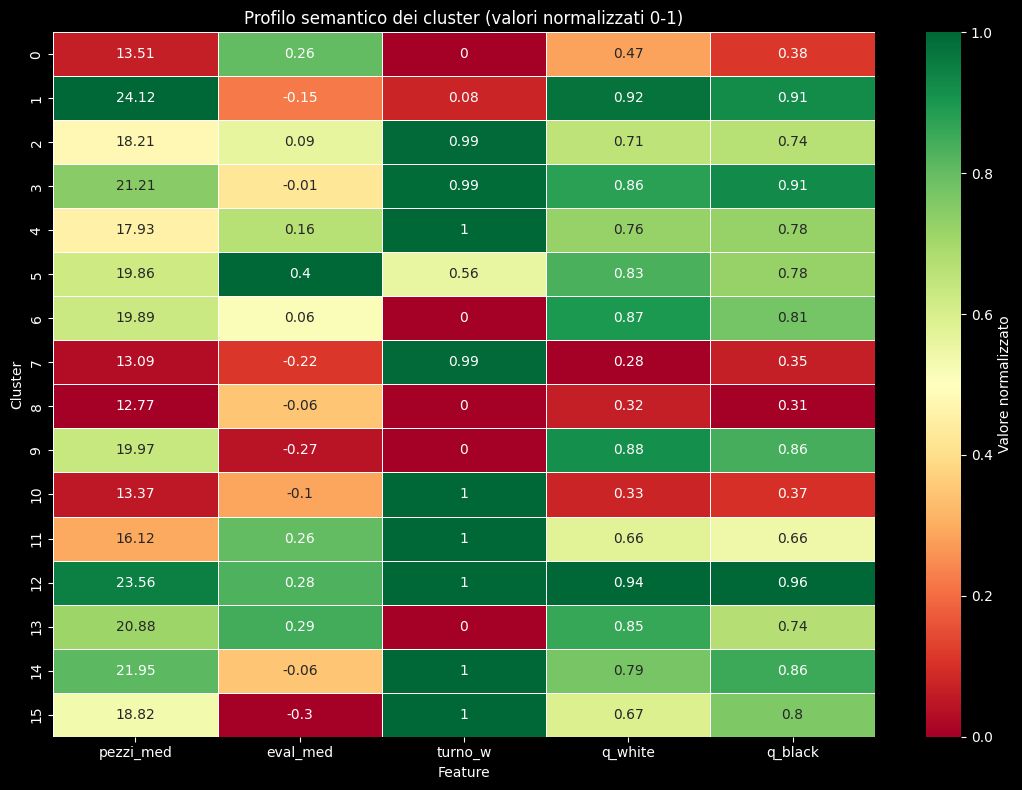

In [15]:
# Riepilogo per cluster
summary = df_feat.groupby('cluster').agg(
    n         = ('n_pieces',   'count'),
    pezzi_med = ('n_pieces',   'mean'),
    eval_med  = ('eval',       'mean'),
    turno_w   = ('turn',       'mean'),  # % posizioni con turno bianco
    q_white   = ('has_q_white','mean'),  # % con donna bianca
    q_black   = ('has_q_black','mean'),  # % con donna nera
).round(3)

# Fase predominante
phase_mode = df_feat.groupby('cluster')['phase'].agg(lambda x: x.mode()[0])
summary['fase'] = phase_mode

print('\n=== Profilo semantico dei cluster ===' )
print(summary.to_string())

# Heatmap delle feature normalizzate
num_cols = ['pezzi_med', 'eval_med', 'turno_w', 'q_white', 'q_black']
heat_data = summary[num_cols].copy()
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-9)

plt.figure(figsize=(11, max(6, K_FINAL // 2)))
sns.heatmap(heat_norm, annot=heat_data.round(2), fmt='g',
            cmap='RdYlGn', linewidths=0.5, cbar_kws={'label': 'Valore normalizzato'})
plt.title('Profilo semantico dei cluster (valori normalizzati 0-1)')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('cluster_semantics.png', dpi=150, bbox_inches='tight')
plt.show()


── Cluster 6 ── n=1070 | pezzi=19.9 | eval=+0.057 | fase=mediogioco | turno_bianco=0%
  Esempio 1: 1r2r1k1/1p2qp1p/6pB/1ppB4/3P2b1/P5P1/1PQ4P/2R1R1K1 b - - 0 23


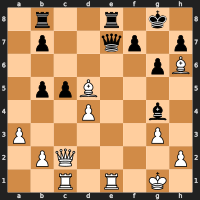

  Esempio 2: r3r1k1/ppR3pp/8/3pN3/3PR3/1p6/PP3PPP/6K1 b - - 0 20


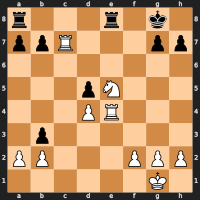


── Cluster 9 ── n=1033 | pezzi=20.0 | eval=-0.272 | fase=mediogioco | turno_bianco=0%
  Esempio 1: 5rk1/pp4pp/2p5/3bNr2/3P1P2/1P1Q2P1/P2R1P1K/5R2 b - - 0 27


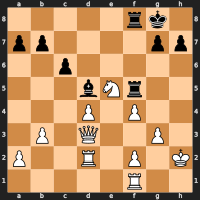

  Esempio 2: r4rk1/5ppp/p1p5/1p2P1q1/3pQ1b1/1B1P4/PPP1RPPP/RN4K1 b - - 0 19


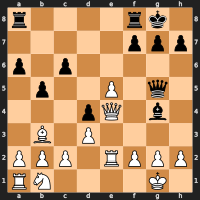


── Cluster 8 ── n=839 | pezzi=12.8 | eval=-0.059 | fase=finale | turno_bianco=0%
  Esempio 1: 8/4k3/1p6/2pPpPp1/K5P1/8/1P6/8 b - - 0 37


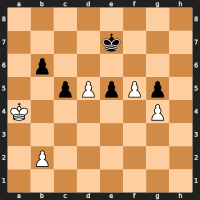

  Esempio 2: 8/8/1P5R/p2p4/3P4/P1P1Pk2/1K4p1/8 b - - 0 52


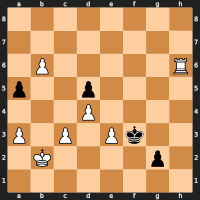


── Cluster 13 ── n=781 | pezzi=20.9 | eval=+0.290 | fase=mediogioco | turno_bianco=0%
  Esempio 1: r1b3k1/ppq2pp1/2p4p/3p3Q/3N4/3B3P/PPP3P1/4R1K1 b - - 0 19


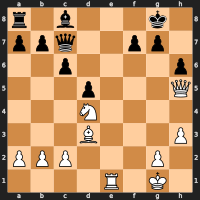

  Esempio 2: r6r/p1p3pp/5qk1/1p6/4Qb2/2P5/PPn3PP/RN3RK1 b - - 3 25


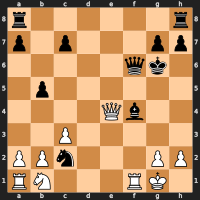

In [16]:
# Mostra le 3 posizioni più rappresentative di ogni cluster
# (quelle più vicine al centroide)
from scipy.spatial.distance import cdist

def show_cluster_samples(cluster_id: int, n: int = 3):
    mask   = cluster_labels == cluster_id
    z_cl   = z_q_np[mask]
    fens_cl = [all_fens[i] for i, m in enumerate(mask) if m]
    center = km_final.cluster_centers_[cluster_id]
    # Trova i più vicini al centroide nello spazio scalato
    z_cl_scaled = z_scaled[mask]
    dists = cdist([center], z_cl_scaled)[0]
    nearest = np.argsort(dists)[:n]
    
    info = summary.loc[cluster_id]
    print(f'\n── Cluster {cluster_id} ── n={int(info["n"])} | '
          f'pezzi={info["pezzi_med"]:.1f} | '
          f'eval={info["eval_med"]:+.3f} | '
          f'fase={info["fase"]} | '
          f'turno_bianco={info["turno_w"]*100:.0f}%')
    
    for i, idx_near in enumerate(nearest):
        fen = fens_cl[idx_near]
        board = chess.Board(fen)
        print(f'  Esempio {i+1}: {fen}')
        display(SVG(chess.svg.board(board, size=200)))

# Mostra i 4 cluster più popolosi
top_clusters = np.argsort([-( cluster_labels == c).sum() for c in range(K_FINAL)])[:4]
for cid in top_clusters:
    show_cluster_samples(cid, n=2)


═══ Cluster 6 | n=1070 | pezzi=19.9 | eval=+0.057 | fase=mediogioco ===
  FEN: 1r2r1k1/1p2qp1p/6pB/1ppB4/3P2b1/P5P1/1PQ4P/2R1R1K1 b - - 0 23
  ORIGINALE                    RICOSTRUITA


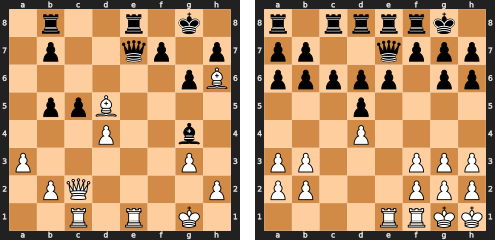

  FEN: r3r1k1/ppR3pp/8/3pN3/3PR3/1p6/PP3PPP/6K1 b - - 0 20
  ORIGINALE                    RICOSTRUITA


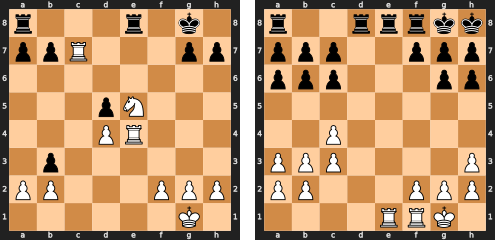


═══ Cluster 9 | n=1033 | pezzi=20.0 | eval=-0.272 | fase=mediogioco ===
  FEN: 5rk1/pp4pp/2p5/3bNr2/3P1P2/1P1Q2P1/P2R1P1K/5R2 b - - 0 27
  ORIGINALE                    RICOSTRUITA


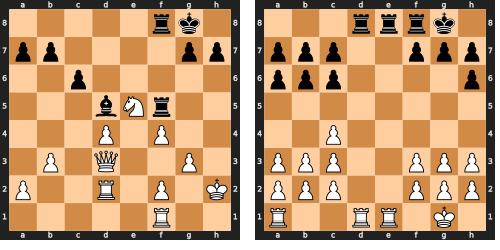

  FEN: r4rk1/5ppp/p1p5/1p2P1q1/3pQ1b1/1B1P4/PPP1RPPP/RN4K1 b - - 0 19
  ORIGINALE                    RICOSTRUITA


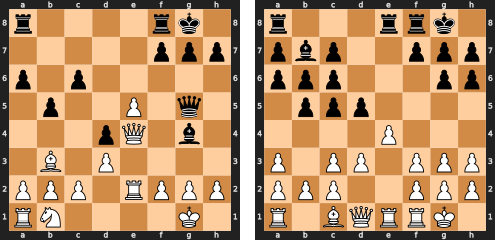


═══ Cluster 8 | n=839 | pezzi=12.8 | eval=-0.059 | fase=finale ===
  FEN: 8/4k3/1p6/2pPpPp1/K5P1/8/1P6/8 b - - 0 37
  ORIGINALE                    RICOSTRUITA


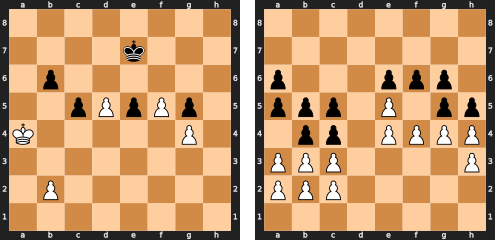

  FEN: 8/8/1P5R/p2p4/3P4/P1P1Pk2/1K4p1/8 b - - 0 52
  ORIGINALE                    RICOSTRUITA


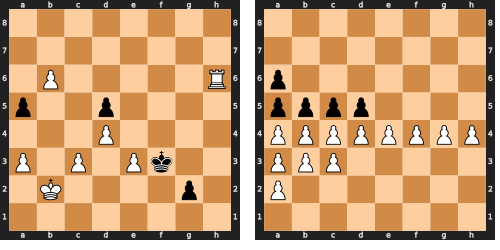


═══ Cluster 13 | n=781 | pezzi=20.9 | eval=+0.290 | fase=mediogioco ===
  FEN: r1b3k1/ppq2pp1/2p4p/3p3Q/3N4/3B3P/PPP3P1/4R1K1 b - - 0 19
  ORIGINALE                    RICOSTRUITA


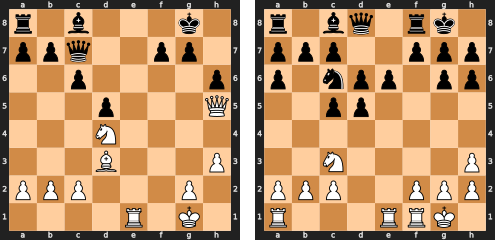

  FEN: r6r/p1p3pp/5qk1/1p6/4Qb2/2P5/PPn3PP/RN3RK1 b - - 3 25
  ORIGINALE                    RICOSTRUITA


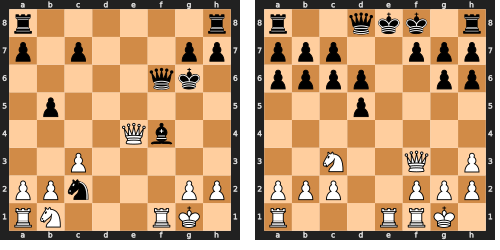

In [17]:
# Mostra originale vs ricostruita per le posizioni rappresentative
def tensor_to_board(t: torch.Tensor, threshold: float = 0.5) -> chess.Board:
    """Converte un tensore (13,8,8) sigmoid in una chess.Board."""
    piece_map = {
        0: chess.Piece(chess.PAWN,   chess.WHITE),
        1: chess.Piece(chess.KNIGHT, chess.WHITE),
        2: chess.Piece(chess.BISHOP, chess.WHITE),
        3: chess.Piece(chess.ROOK,   chess.WHITE),
        4: chess.Piece(chess.QUEEN,  chess.WHITE),
        5: chess.Piece(chess.KING,   chess.WHITE),
        6: chess.Piece(chess.PAWN,   chess.BLACK),
        7: chess.Piece(chess.KNIGHT, chess.BLACK),
        8: chess.Piece(chess.BISHOP, chess.BLACK),
        9: chess.Piece(chess.ROOK,   chess.BLACK),
       10: chess.Piece(chess.QUEEN,  chess.BLACK),
       11: chess.Piece(chess.KING,   chess.BLACK),
    }
    board = chess.Board(None)
    planes = t[:12].numpy()  # (12, 8, 8)
    for rank in range(8):
        for file in range(8):
            sq = chess.square(file, 7 - rank)
            probs = planes[:, rank, file]
            best  = probs.argmax()
            if probs[best] > threshold:
                board.set_piece_at(sq, piece_map[best])
    return board


def show_original_vs_reconstructed(fen: str, title: str = ''):
    """Mostra originale e ricostruita affiancate."""
    transform_fn = ChessTransform(move_vocab=all_moves)
    board_orig = chess.Board(fen)
    t, _, _, _ = transform_fn(fen,
                               list(board_orig.legal_moves)[0].uci() if board_orig.legal_moves else 'e2e4',
                               [], '0')
    with torch.no_grad():
        out = model(t.unsqueeze(0).to(device))
        recon = torch.sigmoid(out['x_recon'][0].cpu())
    board_recon = tensor_to_board(recon)

    print(f'{title}')
    print('  ORIGINALE                    RICOSTRUITA')
    from IPython.display import display, SVG
    display(SVG(
        '<svg width="500" height="250" xmlns="http://www.w3.org/2000/svg">'
        + chess.svg.board(board_orig,  size=240).replace('<svg ', '<svg x="0" y="0" ')
        + chess.svg.board(board_recon, size=240).replace('<svg ', '<svg x="255" y="0" ')
        + '</svg>'
    ))


# Mostra 2 posizioni per ognuno dei 4 cluster più grandi
from scipy.spatial.distance import cdist
top_clusters = np.argsort([-(cluster_labels == c).sum() for c in range(K_FINAL)])[:4]
for cid in top_clusters:
    mask   = cluster_labels == cid
    fens_cl = [all_fens[i] for i, m in enumerate(mask) if m]
    z_cl_scaled = z_scaled[mask]
    center = km_final.cluster_centers_[cid]
    dists  = cdist([center], z_cl_scaled)[0]
    nearest = np.argsort(dists)[:2]
    info = summary.loc[cid]
    print(f'\n═══ Cluster {cid} | n={int(info["n"])} | '
          f'pezzi={info["pezzi_med"]:.1f} | eval={info["eval_med"]:+.3f} | '
          f'fase={info["fase"]} ===')
    for idx_near in nearest:
        show_original_vs_reconstructed(fens_cl[idx_near], f'  FEN: {fens_cl[idx_near]}')


## 8. Interpolazione nello spazio latente

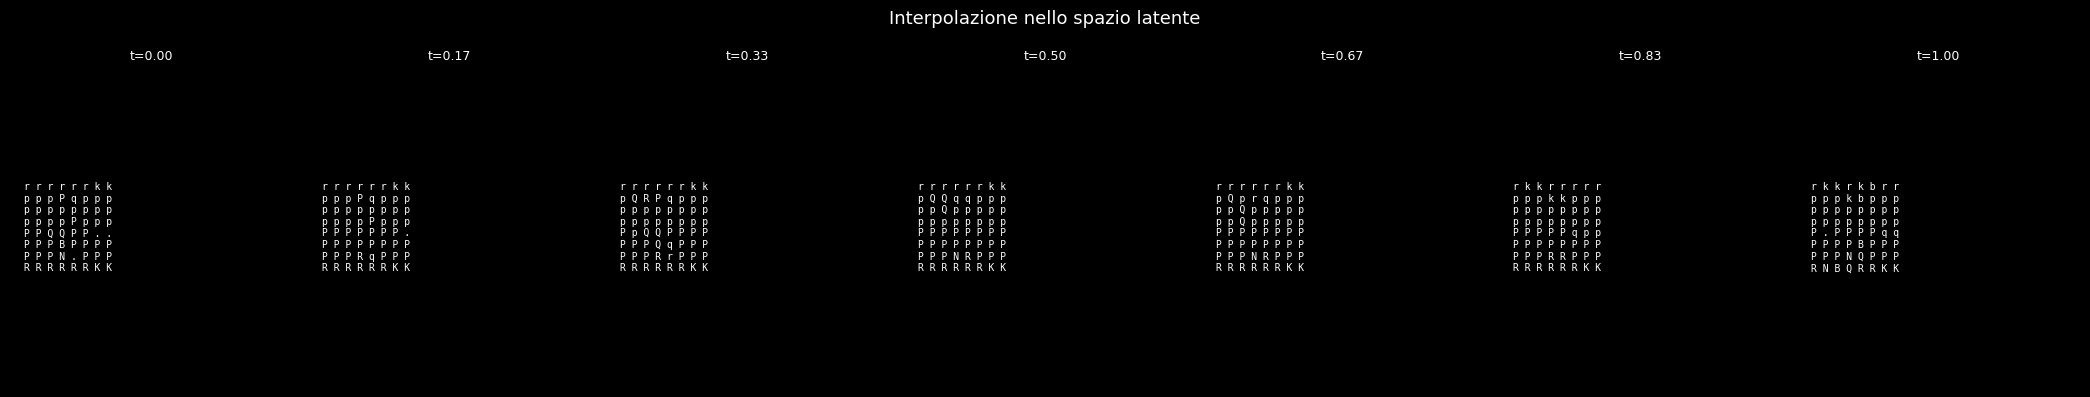

Posizione A (start):


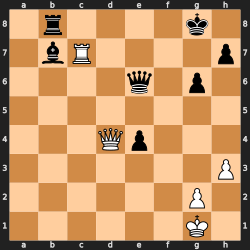

Posizione B (end):


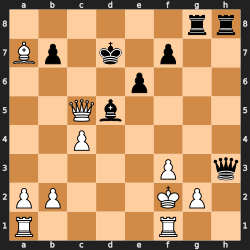

In [18]:
def interpolate_positions(fen_a: str, fen_b: str, n_steps: int = 7):
    """
    Interpola linearmente nello spazio latente tra due posizioni.
    Mostra le posizioni ricostruite lungo il percorso.
    """
    transform_fn = ChessTransform(move_vocab=all_moves)
    
    def fen_to_tensor(fen):
        board = chess.Board(fen)
        t, _, _, _ = transform_fn(fen, list(board.legal_moves)[0].uci() if board.legal_moves else 'e2e4', [], '0')
        return t.unsqueeze(0).to(device)
    
    with torch.no_grad():
        xa = fen_to_tensor(fen_a)
        xb = fen_to_tensor(fen_b)
        za = model.encoder(xa)   # (1, D, 2, 2)
        zb = model.encoder(xb)
    
    fig, axes = plt.subplots(1, n_steps, figsize=(3*n_steps, 4))
    for i, t in enumerate(np.linspace(0, 1, n_steps)):
        z_interp = (1 - t) * za + t * zb
        with torch.no_grad():
            z_q_interp, _, _, _ = model.vq(z_interp)
            x_recon = torch.sigmoid(model.decoder(z_q_interp))
        
        # Ricostruisci scacchiera dalla ricostruzione
        board_recon = chess.Board(None)
        board_recon.clear()
        piece_map = {
            0: chess.Piece(chess.PAWN,   chess.WHITE),
            1: chess.Piece(chess.KNIGHT, chess.WHITE),
            2: chess.Piece(chess.BISHOP, chess.WHITE),
            3: chess.Piece(chess.ROOK,   chess.WHITE),
            4: chess.Piece(chess.QUEEN,  chess.WHITE),
            5: chess.Piece(chess.KING,   chess.WHITE),
            6: chess.Piece(chess.PAWN,   chess.BLACK),
            7: chess.Piece(chess.KNIGHT, chess.BLACK),
            8: chess.Piece(chess.BISHOP, chess.BLACK),
            9: chess.Piece(chess.ROOK,   chess.BLACK),
           10: chess.Piece(chess.QUEEN,  chess.BLACK),
           11: chess.Piece(chess.KING,   chess.BLACK),
        }
        planes = x_recon[0, :12].cpu().numpy()  # (12, 8, 8)
        for rank in range(8):
            for file in range(8):
                sq = chess.square(file, 7 - rank)
                best_plane = planes[:, rank, file].argmax()
                if planes[best_plane, rank, file] > 0.3:
                    board_recon.set_piece_at(sq, piece_map[best_plane])
        
        svg = chess.svg.board(board_recon, size=200)
        from IPython.display import display, SVG
        axes[i].set_title(f't={t:.2f}', fontsize=9)
        axes[i].axis('off')
        # Nota: SVG non si può inserire direttamente in matplotlib
        # Usiamo invece una griglia testuale
        text = str(board_recon).replace('\n', '\n')
        axes[i].text(0.05, 0.5, text, transform=axes[i].transAxes,
                     fontsize=7, fontfamily='monospace', va='center')
    
    plt.suptitle('Interpolazione nello spazio latente', fontsize=13)
    plt.tight_layout()
    plt.savefig('interpolation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Mostra anche le tavole SVG originali
    print('Posizione A (start):')
    display(SVG(chess.svg.board(chess.Board(fen_a), size=250)))
    print('Posizione B (end):')
    display(SVG(chess.svg.board(chess.Board(fen_b), size=250)))


# Esempio: prendi due posizioni da cluster diversi
c0_fens = [all_fens[i] for i, c in enumerate(cluster_labels) if c == 0]
c1_fens = [all_fens[i] for i, c in enumerate(cluster_labels) if c == 1]
if c0_fens and c1_fens:
    interpolate_positions(c0_fens[0], c1_fens[0], n_steps=7)

## 9. Nearest neighbors nel codebook — cosa codifica ogni vettore?

In [19]:
# Per i top-20 vettori più usati, trova le posizioni più vicine
# e calcola cosa hanno in comune

top_vectors = np.argsort(counts)[::-1][:20]

print('Analisi dei 20 vettori del codebook più usati\n')
print(f'{"IDX":>5} {"USI":>7} {"PEZZI":>7} {"EVAL":>8} {"FASE":>12} {"T_W%":>6} {"Q_W%":>6} {"Q_B%":>6}')
print('─' * 60)

for vec_idx in top_vectors:
    # Trova le posizioni che usano questo vettore (in almeno uno dei 4 slot)
    mask_uses = np.any(indices_np == vec_idx, axis=1)
    if mask_uses.sum() == 0:
        continue
    
    sub_df = df_feat[mask_uses]
    fase_mode = sub_df['phase'].mode()[0] if len(sub_df) > 0 else '?'
    
    print(f'{vec_idx:5d} '
          f'{counts[vec_idx]:7d} '
          f'{sub_df.n_pieces.mean():7.1f} '
          f'{sub_df['eval'].mean():+8.3f} '
          f'{fase_mode:>12} '
          f'{sub_df.turn.mean()*100:6.0f}% '
          f'{sub_df.has_q_white.mean()*100:6.0f}% '
          f'{sub_df.has_q_black.mean()*100:6.0f}%')

Analisi dei 20 vettori del codebook più usati

  IDX     USI   PEZZI     EVAL         FASE   T_W%   Q_W%   Q_B%
────────────────────────────────────────────────────────────
  212     233    15.2   -0.332   mediogioco    100%     48%     57%
  485     195    13.6   -0.160       finale    100%     32%     42%
  145     177    18.5   -0.133   mediogioco      0%     76%     76%
  205     166    17.7   -0.115   mediogioco    100%     63%     75%
  318     165    19.3   -0.231   mediogioco     54%     78%     78%
  475     165    14.8   -0.004       finale    100%     43%     48%
    7     162    24.1   -0.268   mediogioco      0%     96%     96%
  392     161    10.6   -0.088       finale     19%     15%     16%
  384     159    19.4   -0.092   mediogioco     42%     68%     74%
   39     159    17.6   +0.316   mediogioco     99%     76%     75%
   28     158    17.1   +0.247   mediogioco     84%     78%     77%
  121     158    14.7   -0.249   mediogioco      0%     54%     51%
  236     1

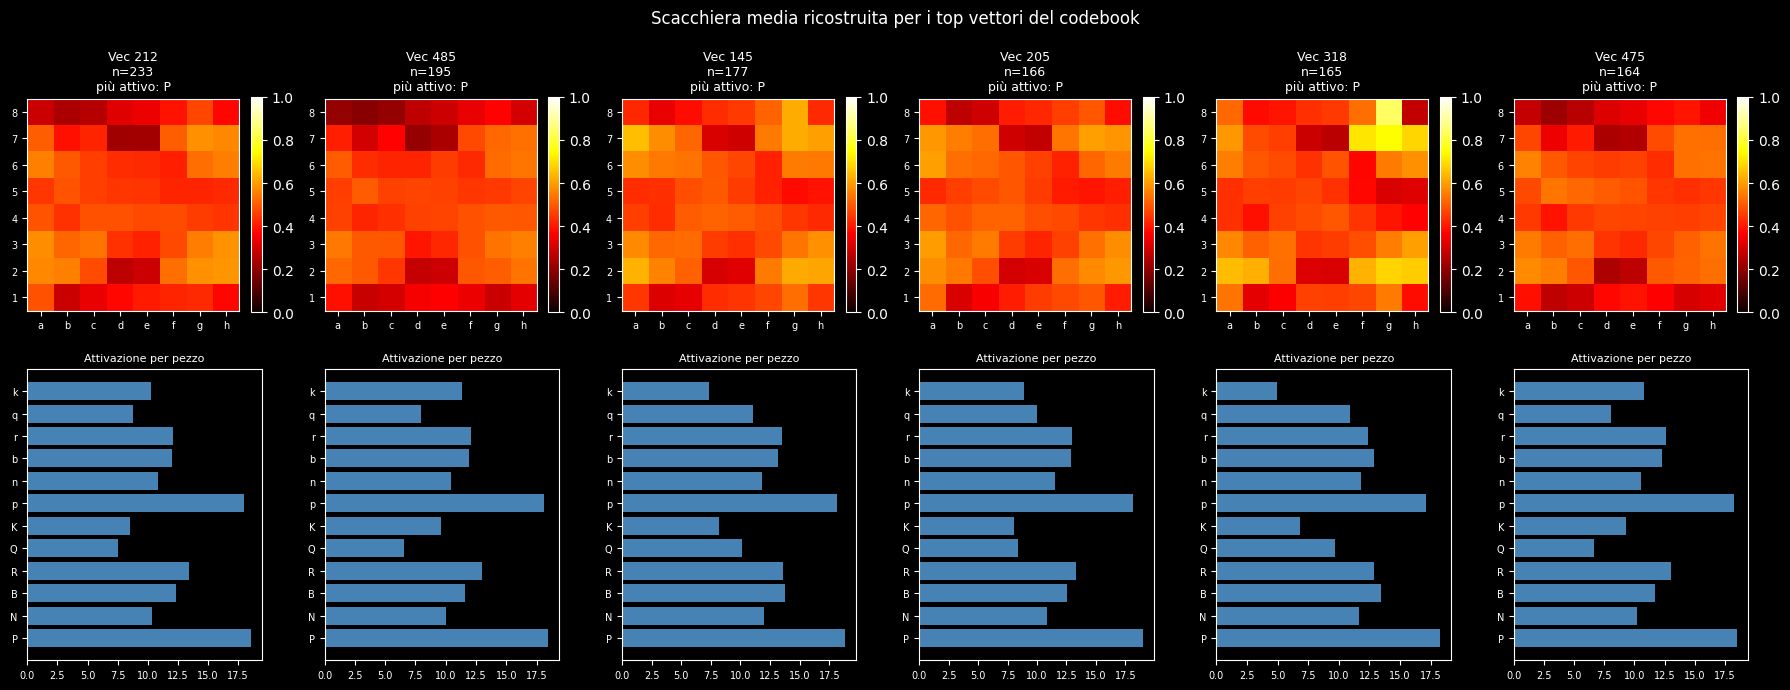

In [20]:
# Visualizza la scacchiera media ricostruita per i top vettori
# (media delle ricostruzioni delle posizioni che usano quel vettore)

TOP_N = 6
fig, axes = plt.subplots(2, TOP_N, figsize=(3*TOP_N, 7))

piece_names = ['P', 'N', 'B', 'R', 'Q', 'K', 'p', 'n', 'b', 'r', 'q', 'k']

for col, vec_idx in enumerate(top_vectors[:TOP_N]):
    mask_uses = np.any(indices_np == vec_idx, axis=1)
    sub_positions = positions_tensor[mask_uses][:50]  # max 50 per velocità
    
    with torch.no_grad():
        recons = torch.sigmoid(model(sub_positions)['x_recon'])  # (N, 13, 8, 8)
    mean_recon = recons[:, :12].mean(0).cpu().numpy()  # (12, 8, 8)
    
    # Quale piano è più attivo?
    activation_per_plane = mean_recon.sum(axis=(1, 2))  # (12,)
    top_piece = np.argmax(activation_per_plane)
    
    # Plot heatmap della scacchiera media
    board_mean = mean_recon.max(axis=0)   # (8, 8) — max over piani
    im = axes[0, col].imshow(board_mean, cmap='hot', vmin=0, vmax=1,
                              origin='upper')
    axes[0, col].set_title(f'Vec {vec_idx}\nn={mask_uses.sum()}\npiù attivo: {piece_names[top_piece]}',
                           fontsize=9)
    axes[0, col].set_xticks(range(8))
    axes[0, col].set_xticklabels(list('abcdefgh'), fontsize=7)
    axes[0, col].set_yticks(range(8))
    axes[0, col].set_yticklabels(list('87654321'), fontsize=7)
    plt.colorbar(im, ax=axes[0, col], fraction=0.046)
    
    # Barchart attivazione per tipo pezzo
    axes[1, col].barh(piece_names, activation_per_plane, color='steelblue')
    axes[1, col].set_title('Attivazione per pezzo', fontsize=8)
    axes[1, col].tick_params(labelsize=7)

plt.suptitle('Scacchiera media ricostruita per i top vettori del codebook', fontsize=12)
plt.tight_layout()
plt.savefig('codebook_semantics.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Analisi della qualità di ricostruzione per tipo di posizione

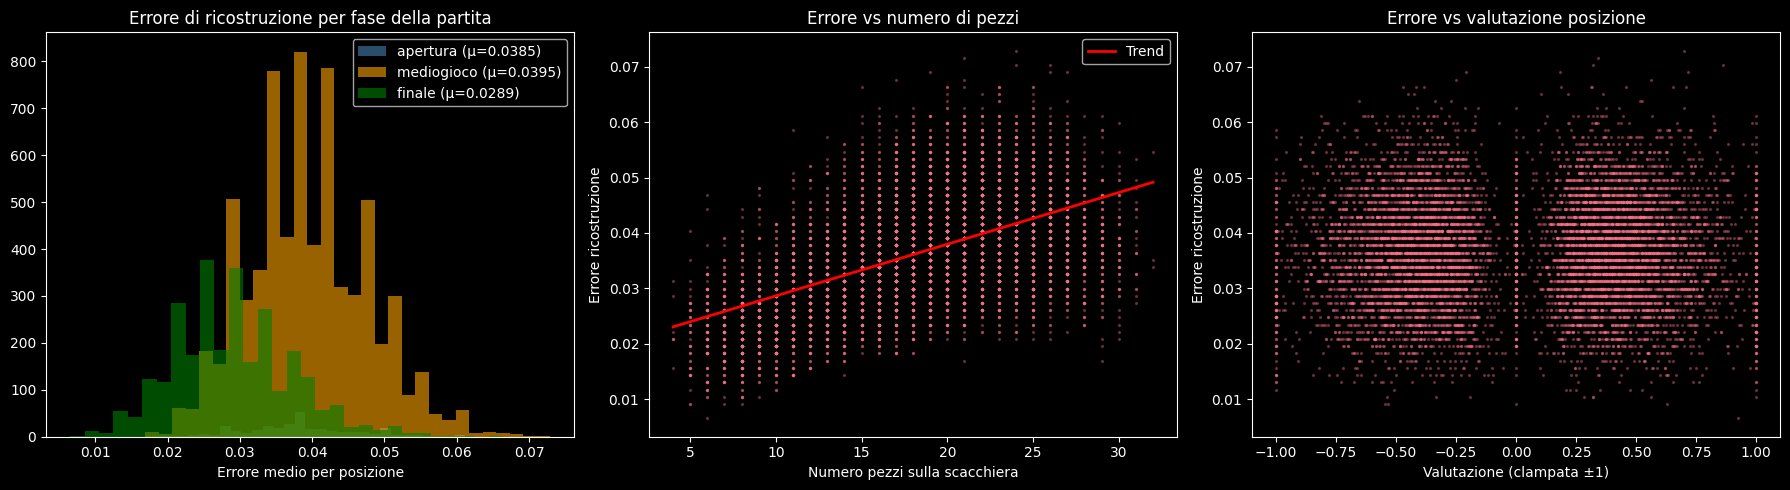

Errore medio globale:      0.0365
Errore apertura:           0.0385
Errore mediogioco:         0.0395
Errore finale:             0.0289


In [21]:
# Errore di ricostruzione per fase della partita
recon_errors = []
with torch.no_grad():
    for i in range(0, len(positions_tensor), BATCH_SIZE):
        batch = positions_tensor[i:i+BATCH_SIZE]
        out = model(batch)
        pred = (torch.sigmoid(out['x_recon'][:, :12]) > 0.5).float()
        err  = (pred != batch[:, :12]).float().mean(dim=(1,2,3)).cpu().numpy()
        recon_errors.extend(err.tolist())

recon_errors = np.array(recon_errors)
df_feat['recon_error'] = recon_errors

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Errore per fase
for phase, color in [('apertura', 'steelblue'), ('mediogioco', 'orange'), ('finale', 'green')]:
    data = recon_errors[df_feat['phase'] == phase]
    axes[0].hist(data, bins=30, alpha=0.6, label=f'{phase} (μ={data.mean():.4f})', color=color)
axes[0].set_title('Errore di ricostruzione per fase della partita')
axes[0].set_xlabel('Errore medio per posizione')
axes[0].legend()

# Errore vs numero pezzi
axes[1].scatter(df_feat['n_pieces'], recon_errors, s=2, alpha=0.3)
# Trend line
z = np.polyfit(df_feat['n_pieces'], recon_errors, 1)
p = np.poly1d(z)
x_line = np.linspace(df_feat['n_pieces'].min(), df_feat['n_pieces'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r-', linewidth=2, label='Trend')
axes[1].set_title('Errore vs numero di pezzi')
axes[1].set_xlabel('Numero pezzi sulla scacchiera')
axes[1].set_ylabel('Errore ricostruzione')
axes[1].legend()

# Errore vs valutazione
axes[2].scatter(np.clip(evals_np, -1, 1), recon_errors, s=2, alpha=0.3)
axes[2].set_title('Errore vs valutazione posizione')
axes[2].set_xlabel('Valutazione (clampata ±1)')
axes[2].set_ylabel('Errore ricostruzione')

plt.tight_layout()
plt.savefig('recon_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Errore medio globale:      {recon_errors.mean():.4f}')
print(f'Errore apertura:           {recon_errors[df_feat["phase"]=="apertura"].mean():.4f}')
print(f'Errore mediogioco:         {recon_errors[df_feat["phase"]=="mediogioco"].mean():.4f}')
print(f'Errore finale:             {recon_errors[df_feat["phase"]=="finale"].mean():.4f}')

=== 3 posizioni MEGLIO ricostruite ===
  FEN: 1r4k1/R7/4P1K1/8/7p/8/8/8 b - - 2 44  errore=0.00651


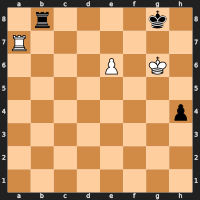

  FEN: 1N1n4/8/8/P1Pp4/1K6/4k3/8/8 b - - 0 53  errore=0.00911


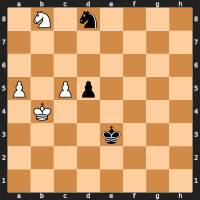

  FEN: 8/8/8/8/R7/P4k2/1K6/6q1 w - - 0 54  errore=0.00911


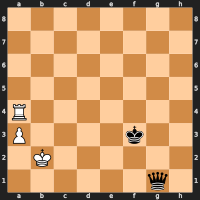

=== 3 posizioni PEGGIO ricostruite ===
  FEN: rnb1k2r/3pq1pp/2p2p2/1p2P3/1P1P2Q1/1p2B3/P1P4p/R4R1K w kq - 0 22  errore=0.07031


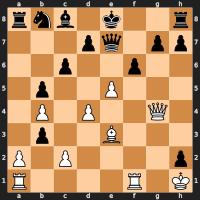

  FEN: 2rq4/pR4bk/6pp/r3p3/2Pp1n1P/3P1N2/3Q1PB1/1R4K1 w - - 1 34  errore=0.07161


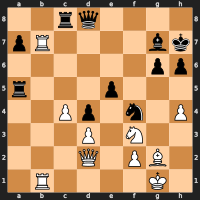

  FEN: r4rk1/1b2ppbp/5q2/3p1PP1/2pP1B2/p1P3Q1/1p5P/1B3RRK b - - 0 29  errore=0.07292


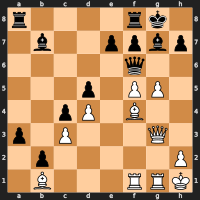

In [22]:
# Mostra le posizioni meglio e peggio ricostruite
best_idx  = np.argsort(recon_errors)[:3]
worst_idx = np.argsort(recon_errors)[-3:]

print('=== 3 posizioni MEGLIO ricostruite ===')
for i in best_idx:
    print(f'  FEN: {all_fens[i]}  errore={recon_errors[i]:.5f}')
    display(SVG(chess.svg.board(chess.Board(all_fens[i]), size=200)))

print('=== 3 posizioni PEGGIO ricostruite ===')
for i in worst_idx:
    print(f'  FEN: {all_fens[i]}  errore={recon_errors[i]:.5f}')
    display(SVG(chess.svg.board(chess.Board(all_fens[i]), size=200)))

In [27]:
# Confronto rapido epoch 2 vs epoch 10
for ckpt_path, label in [
    ('./runs/vqvae/checkpoints/best.pt',        'Epoch 2 (best)'),
    ('./runs/vqvae/checkpoints/epoch_0010.pt', 'Epoch 10'),
]:
    ckpt = torch.load(ckpt_path, map_location='cpu')
    cb   = ckpt['model']['vq.embedding.weight'].float().numpy()
    used = ckpt['model']['vq.ema_cluster_size'].numpy()
    
    from sklearn.decomposition import PCA
    pca2 = PCA(n_components=2).fit_transform(cb)
    entropy = 0
    p = used / used.sum()
    entropy = -np.sum(p[p>0] * np.log(p[p>0]))
    
    print(f'{label}: perplexity={np.exp(entropy):.1f}, '
          f'vettori_usati={(used>1e-4).sum()}, '
          f'spread_PC1={pca2[:,0].std():.3f}')

Epoch 2 (best): perplexity=481.2, vettori_usati=512, spread_PC1=0.462
Epoch 10: perplexity=486.4, vettori_usati=512, spread_PC1=0.469
